In [1]:
# STEP 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.utils import to_categorical

In [3]:
# STEP 2: Load Dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 38s 1us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 3s 1us/step


In [5]:
# STEP 3: Reshape Images
X_train = X_train.reshape(60000, 28, 28, 1)
X_test = X_test.reshape(10000, 28, 28, 1)


In [7]:
# STEP 4: Normalize Data
X_train = X_train / 255.0
X_test = X_test / 255.0


In [9]:
# STEP 5: One Hot Encoding
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

In [11]:
# STEP 6: Build CNN Model
model = Sequential()


In [13]:
# Convolution Layer
model.add(Conv2D(32, (3,3), activation='relu',
                 input_shape=(28,28,1)))


C:\Users\rlokh\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
# Pooling Layer
model.add(MaxPooling2D((2,2)))


In [17]:
# Flatten Layer
model.add(Flatten())


In [19]:
# Fully Connected Layer
model.add(Dense(64, activation='relu'))

In [21]:
# Output Layer
model.add(Dense(10, activation='softmax'))

In [23]:
# STEP 7: Compile Model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:

# STEP 8: Train Model
model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 39s 22ms/step - accuracy: 0.8546 - loss: 0.4110 - val_accuracy: 0.8882 - val_loss: 0.3129
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 42s 22ms/step - accuracy: 0.9004 - loss: 0.2776 - val_accuracy: 0.8950 - val_loss: 0.2855
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.9144 - loss: 0.2354 - val_accuracy: 0.9070 - val_loss: 0.2495
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 37s 22ms/step - accuracy: 0.9250 - loss: 0.2043 - val_accuracy: 0.9133 - val_loss: 0.2457
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.9338 - loss: 0.1799 - val_accuracy: 0.9117 - val_loss: 0.2423


In [27]:
# STEP 9: Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Accuracy:", accuracy * 100)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9119 - loss: 0.2490
Test Accuracy: 91.1899983882904


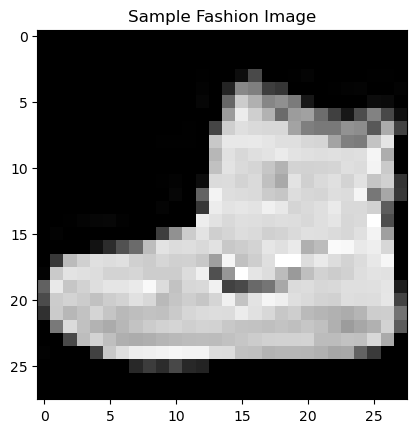

In [31]:
plt.imshow(X_train[0].reshape(28,28), cmap='gray')
plt.title("Sample Fashion Image")
plt.show()